# Tirumala Darshan Forecasting — Daily Pilgrim Crowd Prediction

**Task.** Given data up to and including day *T*, forecast daily pilgrim darshan counts for
days *T+1 … T+14*.

**Data.** Tirumala Tirupati Devasthanams daily darshan counts, Oct 2013 – Jul 2025, with
weather, festival flags and search-interest covariates.

### Design decisions that matter

| Decision | Why |
|---|---|
| No random splits — rolling-origin CV only | A shuffled split leaks future into past through lag features and produces fake accuracy |
| Every lag ≥ 14 days | At a 14-day horizon, `lag_1` does not exist at prediction time |
| Modelling window starts 2022-01-01 | Pre-2018 counts show a digit-distribution artefact; 2018–21 is 31–78% complete |
| `weekday` column dropped | It is 1 only for Wed/Thu/Fri — a broken encoding, not a weekday flag |
| Google Trends renormalised within year | Raw values drift down 62 → 9 due to Trends' window normalisation, opposite to the target |
| Target modelled in log space | Stabilises variance; multiplicative seasonality |

Run cells in order.

## 0 · Setup

In [1]:
!pip install -q lightgbm xgboost optuna holidays shap 2>/dev/null
print("installed")

installed


The system cannot find the path specified.


In [2]:
import warnings, json, os, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import xgboost as xgb

H          = 14            # forecast horizon (days)
HOLDOUT    = 90            # final untouched hold-out (days)
N_FOLDS    = 20            # 20 folds -> 280 OOF points. Needed to calibrate
                           # intervals and to make error-vs-horizon signal, not noise.
MODEL_START= "2022-01-01"  # clean-data window
SEED       = 42
np.random.seed(SEED)

plt.rcParams.update({"figure.figsize":(12,4.2),"axes.grid":True,"grid.alpha":.25,"figure.dpi":110})
pd.set_option("display.width",160)
os.makedirs("artifacts", exist_ok=True)
print(f"H={H}  HOLDOUT={HOLDOUT}  FOLDS={N_FOLDS}  start={MODEL_START}")

H=14  HOLDOUT=90  FOLDS=20  start=2022-01-01


## 1 · Load data

In [3]:
CSV = None
for cand in ["final_data.csv", "/content/final_data.csv"]:
    if os.path.exists(cand): CSV = cand; break

if CSV is None:
    try:
        import kagglehub, glob
        p = kagglehub.dataset_download("vishnumadhav2454/tirumala-tirupati-devasthanam-darshans-dataset")
        CSV = glob.glob(os.path.join(p, "**", "*.csv"), recursive=True)[0]
    except Exception as e:
        print("kagglehub failed:", e)
        from google.colab import files
        up = files.upload(); CSV = list(up.keys())[0]

raw = pd.read_csv(CSV, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print("loaded:", CSV, raw.shape)
print(raw.columns.tolist())
raw.head(3)

loaded: final_data.csv (3572, 17)
['date', 'darshans', 'weekend', 'weekday', 'summer', 'temp_max', 'temp_min', 'humidity', 'rainfall', 'rolling_avg_8', 'google_trend_score', 'is_public_holiday', 'is_festival', 'is_brahmostavam', 'rolling_avg_7', 'day', 'month']


,date,darshans,weekend,weekday,summer,temp_max,temp_min,humidity,rainfall,rolling_avg_8,google_trend_score,is_public_holiday,is_festival,is_brahmostavam,rolling_avg_7,day,month
0,2013-10-16,63426,0,1,0,31.5,24.3,80,4.7,58666.25,60,1,0,0,61020.571429,16,10
1,2013-10-17,56136,0,1,0,30.9,23.4,83,1.0,58666.25,80,0,0,0,61020.571429,17,10
2,2013-10-18,62341,0,1,0,30.5,24.1,81,0.4,58666.25,50,0,0,0,61020.571429,18,10


## 2 · Audit and clean

Three fixes, each justified by a check printed below.

In [4]:
# 2a. weekday column is broken -> confirm, then drop
chk = raw.assign(dow=raw.date.dt.dayofweek).groupby("dow").weekday.mean()
print("mean of `weekday` by day-of-week (Mon=0):")
print(chk.round(2).to_string(), "\n-> 1 only for Wed/Thu/Fri. Broken. Dropping.\n")

# 2b. google_trend_score drifts due to Trends window normalisation
yr = raw.groupby(raw.date.dt.year).google_trend_score.mean()
print("google_trend_score annual mean:"); print(yr.round(1).to_string())
print(f"-> corr with target (raw): {np.corrcoef(raw.google_trend_score, raw.darshans)[0,1]:.3f}")

df0 = raw.drop(columns=["weekday","rolling_avg_7","rolling_avg_8"], errors="ignore").copy()
_g = df0.groupby(df0.date.dt.year).google_trend_score
df0["gt_z"] = ((df0.google_trend_score - _g.transform("mean")) /
                _g.transform("std").replace(0, np.nan)).fillna(0)
print(f"-> corr with target (within-year z): {np.corrcoef(df0.gt_z, df0.darshans)[0,1]:.3f}")
print("   (the raw correlation is inflated by a shared trend artefact; the z version")
print("    measures genuine within-year co-movement, which is the usable signal)\n")

# 2c. reindex to a complete daily calendar so lags are TRUE calendar lags
full = pd.date_range(df0.date.min(), df0.date.max(), freq="D")
df = df0.set_index("date").reindex(full); df.index.name = "date"
print(f"rows {len(df0)} -> reindexed {len(df)} | gap days introduced: {df.darshans.isna().sum()}")
print("(gaps are real closures + scrape misses; target NaN rows get dropped before fitting)")

mean of `weekday` by day-of-week (Mon=0):
dow
0    0.0
1    0.0
2    1.0
3    1.0
4    1.0
5    0.0
6    0.0 
-> 1 only for Wed/Thu/Fri. Broken. Dropping.

google_trend_score annual mean:
date
2013    62.6
2014    53.7
2015    57.6
2016    53.9
2017    44.7
2018    60.7
2019    56.4
2020    41.3
2021     9.3
2022    16.7
2023    20.4
2024    24.7
2025    25.4
-> corr with target (raw): 0.211
-> corr with target (within-year z): 0.146
   (the raw correlation is inflated by a shared trend artefact; the z version
    measures genuine within-year co-movement, which is the usable signal)

rows 3572 -> reindexed 4282 | gap days introduced: 710
(gaps are real closures + scrape misses; target NaN rows get dropped before fitting)


## 3 · Feature engineering

Built as **named blocks** so section 6 can ablate them one at a time. Every lag-derived
feature is shifted by at least `H` days, so nothing in the matrix is unavailable at
forecast time.

In [5]:
# --- BLOCK: calendar ---------------------------------------------------------
d = df.index
df["dow"]=d.dayofweek; df["month"]=d.month; df["doy"]=d.dayofyear
df["woy"]=d.isocalendar().week.astype(int); df["dom"]=d.day
df["is_weekend"]=(df.dow>=5).astype(int)
df["is_month_start"]=(df.dom<=3).astype(int); df["is_month_end"]=(df.dom>=27).astype(int)
for k in range(1,4):
    df[f"w_sin{k}"]=np.sin(2*np.pi*k*df.dow/7);  df[f"w_cos{k}"]=np.cos(2*np.pi*k*df.dow/7)
for k in range(1,6):
    df[f"y_sin{k}"]=np.sin(2*np.pi*k*df.doy/365.25); df[f"y_cos{k}"]=np.cos(2*np.pi*k*df.doy/365.25)
BLK_CAL=[c for c in df.columns if c.startswith(("w_sin","w_cos","y_sin","y_cos"))]+\
        ["dow","month","doy","woy","dom","is_weekend","is_month_start","is_month_end"]
print(f"calendar block: {len(BLK_CAL)} features")

calendar block: 24 features


In [6]:
# --- BLOCK: lunar ------------------------------------------------------------
# Arithmetic lunar phase (mean synodic month). Accurate to ~+/-1 day, which is why the
# continuous phase features matter more than the discrete tithi flags.
SYNODIC, EPOCH = 29.530588853, pd.Timestamp("2000-01-06 18:14")
age = ((df.index - EPOCH).total_seconds()/86400.0) % SYNODIC
df["moon_age"]=age
df["tithi"]=(np.floor(age/SYNODIC*30)+1).astype(int)
df["is_ekadasi"]=df.tithi.isin([11,26]).astype(int)
df["is_purnima"]=(df.tithi==15).astype(int)
df["is_amavasya"]=(df.tithi==30).astype(int)
df["moon_sin"]=np.sin(2*np.pi*age/SYNODIC); df["moon_cos"]=np.cos(2*np.pi*age/SYNODIC)
BLK_LUNAR=["moon_age","is_ekadasi","is_purnima","is_amavasya","moon_sin","moon_cos"]

chk = df.dropna(subset=["darshans"]).groupby("is_ekadasi").darshans.mean()
print(f"lunar block: {len(BLK_LUNAR)} features")
print(f"mean darshans  ekadasi={chk.get(1,np.nan):,.0f}  other={chk.get(0,np.nan):,.0f}")

lunar block: 6 features
mean darshans  ekadasi=68,877  other=68,122


In [7]:
# --- BLOCK: event proximity --------------------------------------------------
# Same-day binaries carry little signal (~4% lift). Distance-to-event is far stronger:
# crowds build BEFORE a festival and decay after.
def proximity(flag):
    pos = pd.Series(np.arange(len(flag)), index=flag.index)
    marks = pos.where(flag.values==1)
    nxt = marks[::-1].ffill()[::-1] - pos          # days until next occurrence
    prv = pos - marks.ffill()                       # days since last occurrence
    return nxt.fillna(99).clip(0,60), prv.fillna(99).clip(0,60)

for c in ["is_festival","is_brahmostavam","is_public_holiday"]:
    df[c]=df[c].fillna(0)
    n,p = proximity(df[c]); df[f"{c}_next"]=n.values; df[f"{c}_prev"]=p.values

# day-number inside a Brahmotsavam run (day 3 != day 7)
b = df.is_brahmostavam.values
run = (np.diff(np.r_[0,b])==1).cumsum()*b
df["brah_day"] = (pd.Series(b,index=df.index).groupby(run).cumsum()*b).values

# bridge days: working day sandwiched between holiday/weekend
off = ((df.is_weekend==1)|(df.is_public_holiday==1)).astype(int)
df["is_bridge"] = ((off==0) & (off.shift(1)==1) & (off.shift(-1)==1)).astype(int)

try:
    import holidays as hol
    ind = hol.India(years=range(int(df.index.year.min()), int(df.index.year.max())+1))
    df["nat_holiday"] = pd.Series(df.index.date, index=df.index).isin(ind).astype(int)
except Exception:
    df["nat_holiday"] = df.is_public_holiday
BLK_EVENT=["is_festival","is_brahmostavam","is_public_holiday","brah_day","is_bridge","nat_holiday"]+\
          [f"{c}_{s}" for c in ["is_festival","is_brahmostavam","is_public_holiday"] for s in ["next","prev"]]
print(f"event block: {len(BLK_EVENT)} features")
print("bridge days:", int(df.is_bridge.sum()), "| brahmotsavam runs:", int(run.max()))

event block: 12 features
bridge days: 47 | brahmotsavam runs: 13


In [8]:
# --- BLOCK: lags & rollings (ALL shifted >= H) -------------------------------
y = df.darshans
LAGS = [H, H+1, H+2, H+7, H+14, 28, 35, 56, 364, 371]   # 364 = 52wk, keeps weekday aligned
for L in LAGS: df[f"lag_{L}"]=y.shift(L)
for w in [7,14,28,56]:
    r = y.shift(H).rolling(w, min_periods=max(2,w//2))
    df[f"rm_{w}"]=r.mean(); df[f"rs_{w}"]=r.std(); df[f"rmin_{w}"]=r.min(); df[f"rmax_{w}"]=r.max()
df["dow_mean_8w"] = y.shift(H).groupby(df.dow).transform(lambda s: s.rolling(8, min_periods=3).mean())
df["trend_ratio"] = df.rm_28/df.rm_56
df["yoy_ratio"]   = df.lag_364/df.lag_371
BLK_LAG=[f"lag_{L}" for L in LAGS]+\
        [f"{p}_{w}" for w in [7,14,28,56] for p in ["rm","rs","rmin","rmax"]]+\
        ["dow_mean_8w","trend_ratio","yoy_ratio"]
print(f"lag block: {len(BLK_LAG)} features | min shift = {H} days (horizon-safe)")

lag block: 29 features | min shift = 14 days (horizon-safe)


In [9]:
# --- BLOCK: weather + exogenous ---------------------------------------------
for c in ["temp_max","temp_min","humidity","rainfall"]:
    df[f"{c}_lag1"]=df[c].shift(1)
df["temp_range"]  = df.temp_max-df.temp_min
df["heavy_rain"]  = (df.rainfall>10).astype(int)
df["rain_weekend"]= df.rainfall*df.is_weekend
df["rain_3d"]     = df.rainfall.rolling(3, min_periods=1).sum()
BLK_WX=["temp_max","temp_min","humidity","rainfall","temp_range","heavy_rain",
        "rain_weekend","rain_3d","gt_z"]+[f"{c}_lag1" for c in ["temp_max","temp_min","humidity","rainfall"]]
print(f"weather/exog block: {len(BLK_WX)} features")

BLOCKS={"calendar":BLK_CAL,"lunar":BLK_LUNAR,"event":BLK_EVENT,"lag":BLK_LAG,"weather":BLK_WX}
FEATS=[c for b in BLOCKS.values() for c in b]
FEATS=list(dict.fromkeys([c for c in FEATS if c in df.columns]))
print(f"\nTOTAL: {len(FEATS)} features across {len(BLOCKS)} blocks")
print({k:len(v) for k,v in BLOCKS.items()})

weather/exog block: 13 features

TOTAL: 83 features across 5 blocks
{'calendar': 24, 'lunar': 6, 'event': 12, 'lag': 29, 'weather': 13}


## 4 · Split

`HOLDOUT` days at the end are untouched until section 12. All model selection and tuning
happens on the development set via rolling-origin CV.

modelling rows : 1268  (2022-01-01 -> 2025-07-06)
dev            : 1178  (2022-01-01 -> 2025-04-07)
hold-out       : 90  (2025-04-08 -> 2025-07-06)
missing cells  : 0.95%  (tree models handle natively)


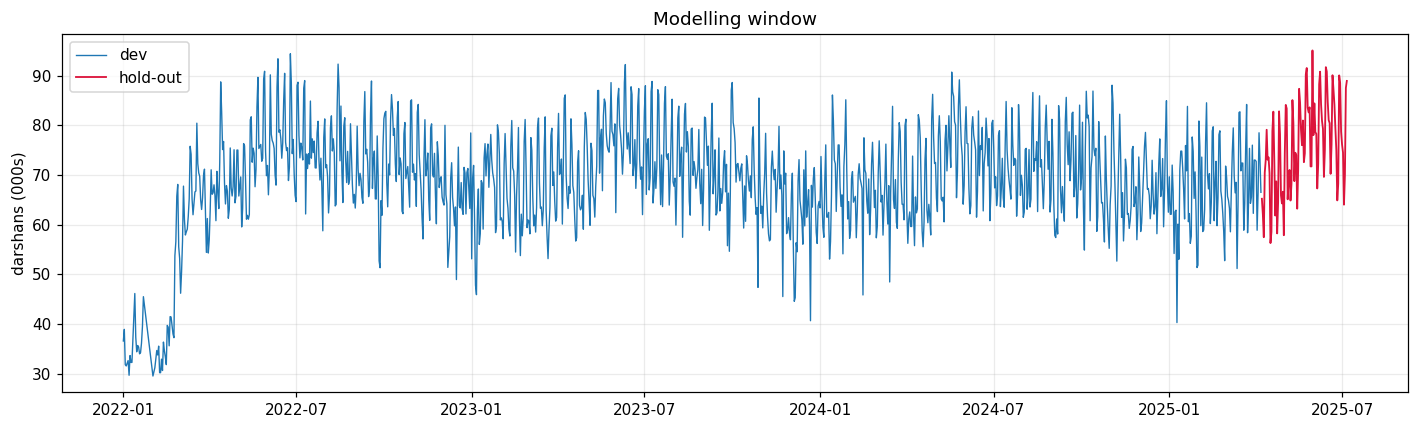

In [10]:
data = df.loc[MODEL_START:].dropna(subset=["darshans"]).copy()
dev, hold = data.iloc[:-HOLDOUT], data.iloc[-HOLDOUT:]

print(f"modelling rows : {len(data)}  ({data.index.min():%Y-%m-%d} -> {data.index.max():%Y-%m-%d})")
print(f"dev            : {len(dev)}  ({dev.index.min():%Y-%m-%d} -> {dev.index.max():%Y-%m-%d})")
print(f"hold-out       : {len(hold)}  ({hold.index.min():%Y-%m-%d} -> {hold.index.max():%Y-%m-%d})")
print(f"missing cells  : {data[FEATS].isna().mean().mean()*100:.2f}%  (tree models handle natively)")

fig,ax=plt.subplots(figsize=(13,4))
ax.plot(dev.index, dev.darshans/1e3, lw=.9, label="dev")
ax.plot(hold.index, hold.darshans/1e3, lw=1.2, color="crimson", label="hold-out")
ax.set_ylabel("darshans (000s)"); ax.set_title("Modelling window"); ax.legend()
plt.tight_layout(); plt.show()

## 5 · Evaluation harness

Rolling-origin (walk-forward) CV. Fold *k* trains on everything up to a cut point and
predicts the next 14 days; the cut then rolls forward. This is the only validation scheme
that respects causality for this problem.

**Skill score** = % reduction in MAE vs. the seasonal-naive baseline. Report this, not raw
MAPE — "31% better than baseline" is interpretable, "MAPE 7.2" is not.

In [11]:
def metrics(a, p):
    a,p = np.asarray(a,float), np.asarray(p,float); e = a-p
    return {"MAE":np.mean(np.abs(e)), "RMSE":np.sqrt(np.mean(e**2)),
            "MAPE":np.mean(np.abs(e/a))*100, "R2":1-np.sum(e**2)/np.sum((a-a.mean())**2)}

def rolling_origin(dset, n_folds=N_FOLDS, horizon=H, min_train=200):
    folds=[]
    for k in range(n_folds):
        end=len(dset)-horizon*k
        tr,te = dset.iloc[:end-horizon], dset.iloc[end-horizon:end]
        if len(tr)<min_train or len(te)<horizon: continue
        folds.append((tr,te))
    return folds[::-1]

FOLDS = rolling_origin(dev)
print(f"{len(FOLDS)} folds x {H} days = {len(FOLDS)*H} validated predictions")
for i,(tr,te) in enumerate(FOLDS):
    print(f"  fold {i}: train {len(tr):4d}d -> test {te.index.min():%Y-%m-%d}..{te.index.max():%Y-%m-%d}")

def cv_eval(make_model, feats, folds=FOLDS, log=True):
    preds, acts, idxs, imps = [], [], [], []
    for tr,te in folds:
        m = make_model()
        ytr = np.log(tr.darshans) if log else tr.darshans
        m.fit(tr[feats], ytr)
        p = m.predict(te[feats]); p = np.exp(p) if log else p
        preds.append(p); acts.append(te.darshans.values); idxs.append(te.index)
        if hasattr(m,"feature_importances_"): imps.append(m.feature_importances_)
    oof = pd.Series(np.concatenate(preds), index=np.concatenate(idxs))
    imp = pd.Series(np.mean(imps,axis=0), index=feats) if imps else None
    return metrics(np.concatenate(acts), np.concatenate(preds)), oof, imp
def lgbm(): return lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
        min_child_samples=20, subsample=0.9, subsample_freq=1, colsample_bytree=0.8,
        random_state=SEED, verbose=-1)

print("\nharness ready")

20 folds x 14 days = 280 validated predictions
  fold 0: train  898d -> test 2024-07-02..2024-07-15
  fold 1: train  912d -> test 2024-07-16..2024-07-29
  fold 2: train  926d -> test 2024-07-30..2024-08-12
  fold 3: train  940d -> test 2024-08-13..2024-08-26
  fold 4: train  954d -> test 2024-08-27..2024-09-09
  fold 5: train  968d -> test 2024-09-10..2024-09-23
  fold 6: train  982d -> test 2024-09-24..2024-10-07
  fold 7: train  996d -> test 2024-10-08..2024-10-21
  fold 8: train 1010d -> test 2024-10-22..2024-11-04
  fold 9: train 1024d -> test 2024-11-05..2024-11-18
  fold 10: train 1038d -> test 2024-11-19..2024-12-02
  fold 11: train 1052d -> test 2024-12-03..2024-12-16
  fold 12: train 1066d -> test 2024-12-17..2024-12-30
  fold 13: train 1080d -> test 2024-12-31..2025-01-13
  fold 14: train 1094d -> test 2025-01-14..2025-01-27
  fold 15: train 1108d -> test 2025-01-28..2025-02-10
  fold 16: train 1122d -> test 2025-02-11..2025-02-24
  fold 17: train 1136d -> test 2025-02-25..20

## 6 · Baselines — the number every model must beat

In [12]:
base_rows=[]
a  = np.concatenate([te.darshans.values for _,te in FOLDS])
ix = np.concatenate([te.index for _,te in FOLDS])
s  = data.darshans

for name, pred in {
    "Naive (lag-14)"            : s.shift(H).reindex(ix).values,
    "Seasonal naive (lag-364)"  : s.shift(364).reindex(ix).values,
    "DOW mean, trailing 8w"     : data["dow_mean_8w"].reindex(ix).values,
    "Rolling mean 28d"          : data["rm_28"].reindex(ix).values,
}.items():
    m = ~np.isnan(pred)
    base_rows.append({"model":name, **metrics(a[m], pred[m]), "n":m.sum()})

BASE = pd.DataFrame(base_rows).set_index("model").sort_values("MAE")
print(BASE.round(2).to_string())

# Reference for skill score = the weekday-aligned naive (lag-14 = 2 whole weeks, so the
# same day of week). This is the conventional forecasting benchmark and the shortest
# legal naive at h=14.
BASELINE_MAE = BASE.loc["Naive (lag-14)","MAE"]
STRONG_MAE   = BASE.MAE.min()
STRONG_NAME  = BASE.MAE.idxmin()
print(f"\n>>> BASELINE_MAE (naive, lag-14) = {BASELINE_MAE:,.0f}  <- skill measured vs this")
print(f">>> STRONG heuristic  = {STRONG_NAME}: {STRONG_MAE:,.0f}")
print("    Note: the day-of-week heuristic is a genuinely strong baseline. A model that")
print("    beats the naive but loses to this has not earned its complexity — report both.")

                              MAE     RMSE   MAPE    R2    n
model                                                       
DOW mean, trailing 8w     4892.12  6244.63   7.30  0.43  280
Naive (lag-14)            6348.66  8238.04   9.42 -0.00  280
Seasonal naive (lag-364)  6448.91  8268.21   9.36 -0.01  280
Rolling mean 28d          6797.75  8230.14  10.09  0.00  280

>>> BASELINE_MAE (naive, lag-14) = 6,349  <- skill measured vs this
>>> STRONG heuristic  = DOW mean, trailing 8w: 4,892
    Note: the day-of-week heuristic is a genuinely strong baseline. A model that
    beats the naive but loses to this has not earned its complexity — report both.


## 7 · Feature ablation — do the blocks earn their place?

Add one block at a time, measure MAE. This table is the single most persuasive slide you
can build: it shows the features were *reasoned about*, not thrown in.

=== CUMULATIVE (adding blocks) ===
          n_feats      MAE     RMSE  MAPE    R2  skill %   Δ MAE
+ block                                                         
lag            28  5169.95  6670.11  7.68  0.34    18.57    0.00
calendar       52  4756.04  6155.80  7.01  0.44    25.09 -413.91
event          64  4822.53  6198.50  7.09  0.43    24.04   66.50
weather        77  4734.51  6116.40  6.96  0.45    25.43  -88.02
lunar          83  4731.67  6021.15  6.95  0.47    25.47   -2.84

=== LEAVE-ONE-BLOCK-OUT (positive Δ = block was helping) ===
                     n_feats      MAE  MAPE   Δ MAE
dropped                                            
lag                       55  5492.82  8.04  745.95
calendar                  59  5037.66  7.43  290.79
weather                   70  4776.78  6.99   29.90
none (all features)       83  4746.88  6.97    0.00
lunar                     77  4679.71  6.87  -67.17
event                     71  4678.26  6.87  -68.61


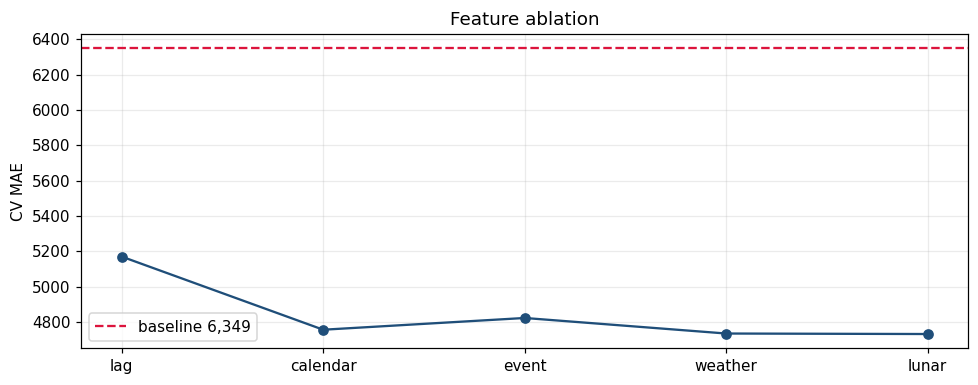

In [13]:
# Cumulative: lag block FIRST. Without it the model has no level information and the
# early rows of the table are meaningless rather than informative.
order=["lag","calendar","event","weather","lunar"]
abl=[]; cum=[]
for blk in order:
    cum = list(dict.fromkeys(cum + [c for c in BLOCKS[blk] if c in df.columns]))
    m,_,_ = cv_eval(lgbm, cum)
    abl.append({"+ block":blk, "n_feats":len(cum), **m,
                "skill %":(1-m["MAE"]/BASELINE_MAE)*100})
ABL=pd.DataFrame(abl).set_index("+ block")
ABL["Δ MAE"]=ABL.MAE.diff().fillna(0)
print("=== CUMULATIVE (adding blocks) ===")
print(ABL.round(2).to_string())

# Leave-one-block-out: the more robust read. How much does DROPPING each block cost?
full_m,_,_ = cv_eval(lgbm, FEATS)
loo=[{"dropped":"none (all features)","n_feats":len(FEATS),"MAE":full_m["MAE"],"MAPE":full_m["MAPE"],"Δ MAE":0.0}]
for blk in BLOCKS:
    keep=[c for c in FEATS if c not in BLOCKS[blk]]
    m,_,_ = cv_eval(lgbm, keep)
    loo.append({"dropped":blk,"n_feats":len(keep),"MAE":m["MAE"],"MAPE":m["MAPE"],
                "Δ MAE":m["MAE"]-full_m["MAE"]})
LOO=pd.DataFrame(loo).set_index("dropped").sort_values("Δ MAE", ascending=False)
print("\n=== LEAVE-ONE-BLOCK-OUT (positive Δ = block was helping) ===")
print(LOO.round(2).to_string())
LOO.to_csv("artifacts/ablation_loo.csv")

fig,ax=plt.subplots(figsize=(9,3.6))
ax.plot(ABL.index, ABL.MAE, "-o", color="#1f4e79")
ax.axhline(BASELINE_MAE, ls="--", color="crimson", label=f"baseline {BASELINE_MAE:,.0f}")
ax.set_ylabel("CV MAE"); ax.set_title("Feature ablation"); ax.legend()
plt.tight_layout(); plt.show()
ABL.to_csv("artifacts/ablation.csv")

## 8 · Model ladder

In [14]:
MODELS={
 "Ridge":        lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=3.0)),
 "RandomForest": lambda: make_pipeline(SimpleImputer(strategy="median"),
                    RandomForestRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=SEED)),
 "ExtraTrees":   lambda: make_pipeline(SimpleImputer(strategy="median"),
                    ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=SEED)),
 "LightGBM":     lgbm,
 "XGBoost":      lambda: xgb.XGBRegressor(n_estimators=700, learning_rate=0.03, max_depth=5,
                    subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
                    random_state=SEED, verbosity=0, n_jobs=-1),
}
try:
    from catboost import CatBoostRegressor
    MODELS["CatBoost"]=lambda: CatBoostRegressor(iterations=700, learning_rate=0.03, depth=6,
                                                 random_seed=SEED, verbose=0, allow_writing_files=False)
except Exception: print("catboost unavailable - skipping")

rows={}; OOF={}; IMP={}
for name, fn in MODELS.items():
    t0=time.time(); m,oof,imp = cv_eval(fn, FEATS)
    rows[name]={**m, "skill_vs_naive %":(1-m["MAE"]/BASELINE_MAE)*100,
                "skill_vs_heuristic %":(1-m["MAE"]/STRONG_MAE)*100, "fit_s":time.time()-t0}
    OOF[name]=oof
    if imp is not None: IMP[name]=imp
    print(f"  {name:14s} MAE {m['MAE']:8,.0f}  MAPE {m['MAPE']:5.2f}%  "
          f"vs-naive {rows[name]['skill_vs_naive %']:5.1f}%  vs-heuristic {rows[name]['skill_vs_heuristic %']:5.1f}%")

LADDER=pd.DataFrame(rows).T.sort_values("MAE")
print("\n=== MODEL LADDER ===")
print(LADDER.round(2).to_string())
LADDER.to_csv("artifacts/model_ladder.csv")

  Ridge          MAE    5,288  MAPE  7.72%  vs-naive  16.7%  vs-heuristic  -8.1%
  RandomForest   MAE    4,377  MAPE  6.45%  vs-naive  31.1%  vs-heuristic  10.5%
  ExtraTrees     MAE    4,401  MAPE  6.51%  vs-naive  30.7%  vs-heuristic  10.0%
  LightGBM       MAE    4,747  MAPE  6.97%  vs-naive  25.2%  vs-heuristic   3.0%
  XGBoost        MAE    4,384  MAPE  6.43%  vs-naive  30.9%  vs-heuristic  10.4%
  CatBoost       MAE    4,373  MAPE  6.43%  vs-naive  31.1%  vs-heuristic  10.6%

=== MODEL LADDER ===
                  MAE     RMSE  MAPE    R2  skill_vs_naive %  skill_vs_heuristic %  fit_s
CatBoost      4373.05  5620.89  6.43  0.53             31.12                 10.61  45.90
RandomForest  4376.75  5673.36  6.45  0.53             31.06                 10.53  29.06
XGBoost       4384.45  5693.25  6.43  0.52             30.94                 10.38  28.71
ExtraTrees    4401.24  5667.63  6.51  0.53             30.67                 10.03  11.34
LightGBM      4746.88  6076.82  6.97  0.46

model  CatBoost  ExtraTrees  LightGBM  RandomForest   Ridge  XGBoost
fold                                                                
0        3455.0      3827.0    3781.0        3957.0  5937.0   3591.0
1        3069.0      2847.0    3626.0        3205.0  3372.0   2757.0
2        2527.0      3505.0    2901.0        3275.0  4915.0   2974.0
3        3756.0      3478.0    3928.0        3738.0  5260.0   4120.0
4        4029.0      4747.0    4431.0        4753.0  4173.0   4266.0
5        3546.0      3916.0    3954.0        3944.0  6159.0   3598.0
6        4800.0      5337.0    5771.0        5436.0  5419.0   5051.0
7        5067.0      5082.0    5156.0        5587.0  5267.0   4853.0
8        7321.0      6664.0    7184.0        7012.0  5067.0   7027.0
9        4716.0      4462.0    4494.0        4239.0  5895.0   4357.0
10       2478.0      2263.0    3080.0        2792.0  2548.0   3262.0
11       5572.0      5380.0    7478.0        5100.0  5600.0   5803.0
12       5666.0      4715.0    622

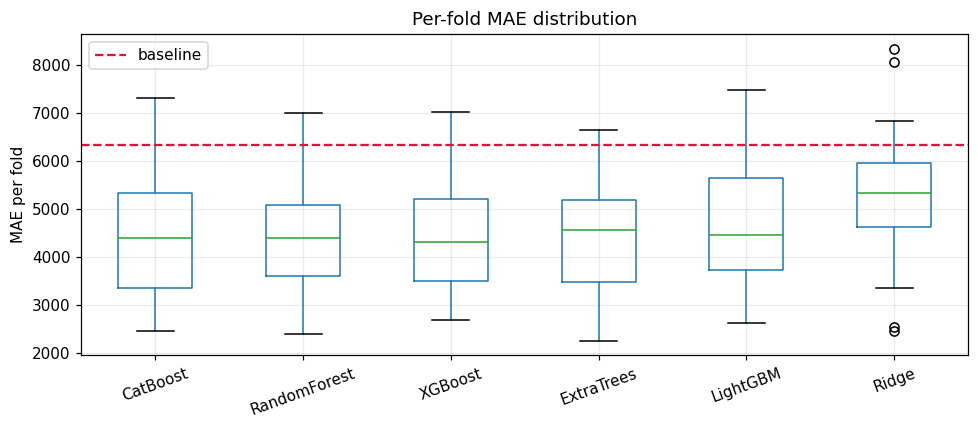

In [15]:
# per-fold variance: is the winner genuinely better, or lucky on one fold?
pf=[]
for name in LADDER.index:
    for i,(tr,te) in enumerate(FOLDS):
        p=OOF[name].reindex(te.index)
        pf.append({"model":name,"fold":i,"MAE":metrics(te.darshans,p)["MAE"]})
PF=pd.DataFrame(pf)
piv=PF.pivot(index="fold",columns="model",values="MAE")
print(piv.round(0).to_string())
print("\nmean / std across folds:")
print(piv.agg(["mean","std"]).round(0).to_string())

fig,ax=plt.subplots(figsize=(9,4))
piv[LADDER.index].boxplot(ax=ax)
ax.axhline(BASELINE_MAE, ls="--", color="crimson", label="baseline")
ax.set_ylabel("MAE per fold"); ax.set_title("Per-fold MAE distribution"); ax.legend()
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 9 · Hyperparameter tuning — Optuna with a time-series objective

**Why Bayesian search, not grid search.** Tree hyperparameters interact strongly:
`learning_rate` × `n_estimators`, `num_leaves` × `min_child_samples`. A grid sweeps each axis
independently and needs exponentially many trials to find a joint optimum. Optuna's TPE
sampler models the objective surface and concentrates trials where they pay off.

**The critical detail:** the objective is the *rolling-origin CV MAE*, not a random-split
score. Tuning against a leaky objective just tunes for leakage.

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_FOLDS = FOLDS[-8:]   # tuning on too few folds overfits the search to
                          # whichever weeks happen to be easy

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 300, 1500, step=100),
        learning_rate    = trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 8, 96),
        max_depth        = trial.suggest_int("max_depth", 3, 12),
        min_child_samples= trial.suggest_int("min_child_samples", 5, 60),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    )
    mk = lambda: lgb.LGBMRegressor(**params, subsample_freq=1, random_state=SEED, verbose=-1)
    m,_,_ = cv_eval(mk, FEATS, folds=TUNE_FOLDS)
    return m["MAE"]

study = optuna.create_study(direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner())
t0=time.time(); N_TRIALS = 40   # raise to 150+ if you have runtime to spare
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"{len(study.trials)} trials in {time.time()-t0:.0f}s")
print(f"best CV MAE: {study.best_value:,.0f}")
print("best params:"); print(json.dumps(study.best_params, indent=2))
json.dump(study.best_params, open("artifacts/best_params.json","w"), indent=2)

40 trials in 150s
best CV MAE: 4,461
best params:
{
  "n_estimators": 800,
  "learning_rate": 0.006239625021484269,
  "num_leaves": 46,
  "max_depth": 4,
  "min_child_samples": 9,
  "subsample": 0.9994435629776057,
  "colsample_bytree": 0.7805895279425341,
  "reg_alpha": 0.07353573238906531,
  "reg_lambda": 0.0011207534873257025
}


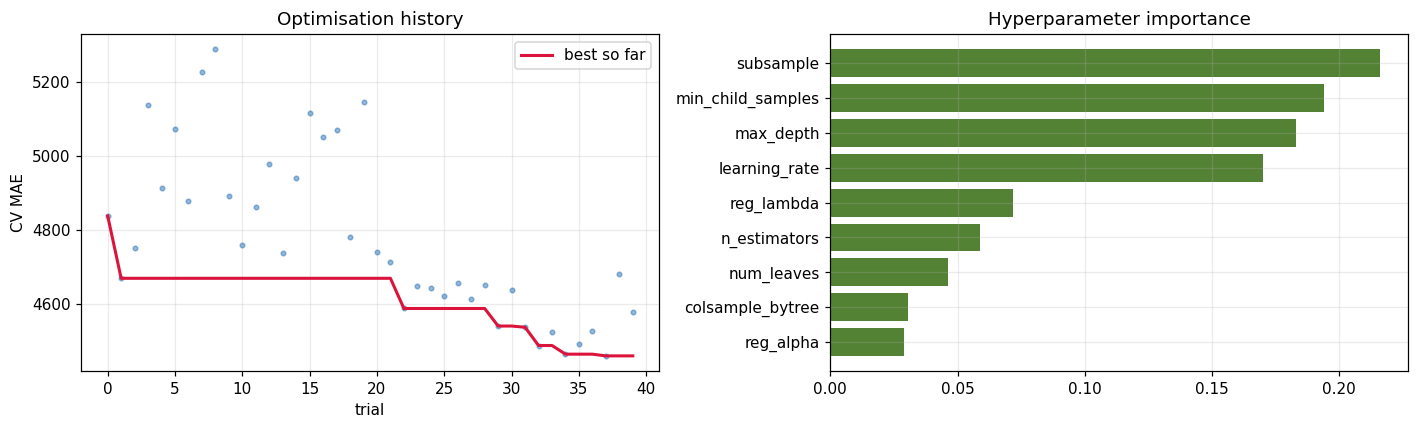

Interpretation: parameters at the top drove most of the improvement;
those at the bottom were largely irrelevant on this dataset.

Tuned LightGBM (all folds): MAE 4,426 | MAPE 6.48% | skill 30.3%
vs untuned LightGBM MAE 4,747  -> improvement +6.8%


In [17]:
# Tuning diagnostics - two ready-made slides
fig,axes=plt.subplots(1,2,figsize=(13,4))
vals=[t.value for t in study.trials if t.value is not None]
axes[0].plot(vals, "o", ms=3, alpha=.5, color="#2e75b6")
axes[0].plot(pd.Series(vals).cummin(), lw=2, color="crimson", label="best so far")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV MAE"); axes[0].set_title("Optimisation history"); axes[0].legend()

imp = optuna.importance.get_param_importances(study)
axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="#548235")
axes[1].set_title("Hyperparameter importance")
plt.tight_layout(); plt.show()

print("Interpretation: parameters at the top drove most of the improvement;")
print("those at the bottom were largely irrelevant on this dataset.")

TUNED = lambda: lgb.LGBMRegressor(**study.best_params, subsample_freq=1, random_state=SEED, verbose=-1)
m_t, oof_t, imp_t = cv_eval(TUNED, FEATS)
OOF["LGBM_tuned"]=oof_t; IMP["LGBM_tuned"]=imp_t
print(f"\nTuned LightGBM (all folds): MAE {m_t['MAE']:,.0f} | MAPE {m_t['MAPE']:.2f}% | "
      f"skill {(1-m_t['MAE']/BASELINE_MAE)*100:.1f}%")
print(f"vs untuned LightGBM MAE {LADDER.loc['LightGBM','MAE']:,.0f}  "
      f"-> improvement {(1-m_t['MAE']/LADDER.loc['LightGBM','MAE'])*100:+.1f}%")

## 10 · Ensembling

Averaging models only helps when their **errors are decorrelated**. Show the residual
correlation matrix first — it explains *why* the ensemble works, which is the difference
between an engineering decision and a lucky guess.

Then stack: fit a Ridge meta-learner on out-of-fold predictions rather than using a flat
average, so each base model gets the weight it earns.

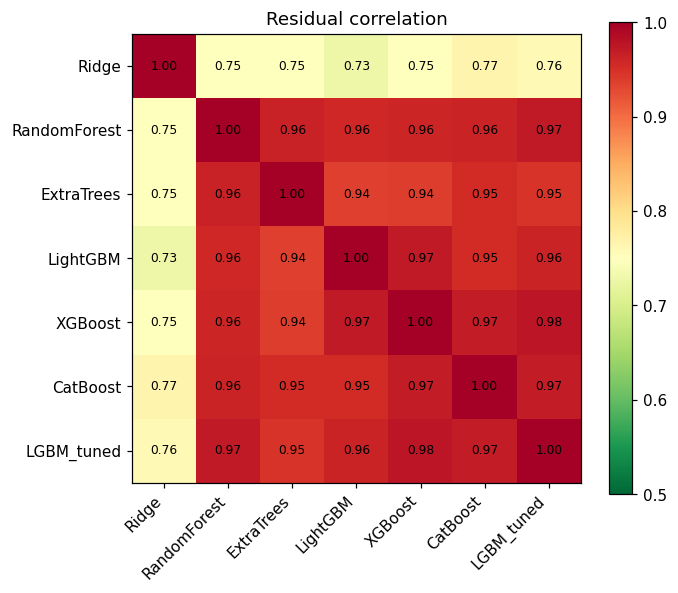

least-correlated pairs (best ensemble candidates):
Ridge  LightGBM        0.728
       XGBoost         0.748
       ExtraTrees      0.751
       RandomForest    0.751


In [18]:
common = sorted(set.intersection(*[set(v.index) for v in OOF.values()]))
P = pd.DataFrame({k:v.reindex(common) for k,v in OOF.items()})
A = data.darshans.reindex(common)
R = P.sub(A, axis=0)                       # residuals

C = R.corr()
fig,ax=plt.subplots(figsize=(6.5,5.5))
im=ax.imshow(C, cmap="RdYlGn_r", vmin=0.5, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=45, ha="right")
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.columns)
for i in range(len(C)):
    for j in range(len(C)): ax.text(j,i,f"{C.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8)
ax.set_title("Residual correlation"); ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()

pairs = C.where(np.triu(np.ones(C.shape),1).astype(bool)).stack().sort_values()
print("least-correlated pairs (best ensemble candidates):")
print(pairs.head(4).round(3).to_string())

In [19]:
# Simple average vs weighted stack
ens_rows=[]
best_single = LADDER.index[0]
ens_rows.append({"method":f"best single ({best_single})", **metrics(A, P[best_single])})
ens_rows.append({"method":"simple average (all)", **metrics(A, P.mean(axis=1))})

top3 = list(LADDER.index[:3])
ens_rows.append({"method":f"average top-3", **metrics(A, P[top3].mean(axis=1))})

# Stacked Ridge with non-negative-ish regularisation, evaluated by internal time split
cut=int(len(P)*0.7)
meta = Ridge(alpha=1.0, positive=True).fit(P.iloc[:cut], A.iloc[:cut])
stack_pred = pd.Series(meta.predict(P), index=P.index)
ens_rows.append({"method":"stacked Ridge", **metrics(A.iloc[cut:], stack_pred.iloc[cut:])})

ENS=pd.DataFrame(ens_rows).set_index("method")
ENS["skill_vs_naive %"]=(1-ENS.MAE/BASELINE_MAE)*100
ENS["skill_vs_heuristic %"]=(1-ENS.MAE/STRONG_MAE)*100
print(ENS.round(2).to_string())
print("\nstack weights:")
print(pd.Series(meta.coef_, index=P.columns).round(3).sort_values(ascending=False).to_string())
ENS.to_csv("artifacts/ensemble.csv")

                            MAE     RMSE  MAPE    R2  skill_vs_naive %  skill_vs_heuristic %
method                                                                                      
best single (CatBoost)  4373.05  5620.89  6.43  0.53             31.12                 10.61
simple average (all)    4333.41  5623.89  6.36  0.53             31.74                 11.42
average top-3           4314.41  5590.87  6.34  0.54             32.04                 11.81
stacked Ridge           4197.95  5315.41  6.29  0.57             33.88                 14.19

stack weights:
CatBoost        0.300
ExtraTrees      0.285
XGBoost         0.210
Ridge           0.128
RandomForest    0.015
LightGBM        0.000
LGBM_tuned      0.000


## 11 · Prediction intervals — conformalised

A point forecast is not actionable for crowd management; operations needs a range to staff
against. Raw quantile regression on ~1,200 rows overfits and produces intervals that are far
too narrow — check the printed coverage before and after.

**Conformalised Quantile Regression** fixes that with a distribution-free guarantee: split the
out-of-fold predictions into calibration and test, measure how far outside its interval each
actual value fell, and widen by the 90th percentile of that score. Coverage of *at least* 90%
then holds by construction.

pinball q=0.05: 843
pinball q=0.5: 2,168
pinball q=0.95: 717

RAW quantile coverage  :  70.0%   (target 90) <- uncalibrated
CQR-calibrated coverage:  90.7%   (calibrated on 140, tested on 140)
  widening qhat        : 3,523
  raw width            : 12,483
  calibrated width     : 20,094

CQR guarantees AT LEAST 90% coverage, so landing above 90 is expected and safe.
Report it as conservative rather than tuning until it reads exactly 90 --
that would discard the guarantee, which is the whole point of the method.


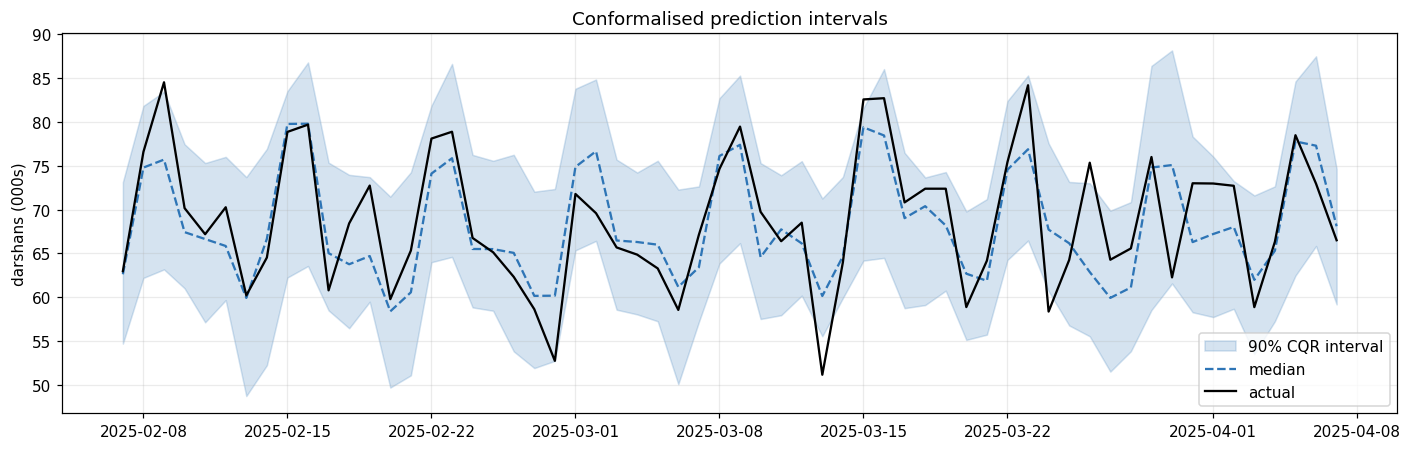

In [20]:
QS=[0.05,0.5,0.95]; qpred={}
for q in QS:
    mk=lambda q=q: lgb.LGBMRegressor(objective="quantile", alpha=q, n_estimators=400,
        learning_rate=0.05, num_leaves=15, min_child_samples=25,
        random_state=SEED, verbose=-1)
    _,o,_ = cv_eval(mk, FEATS); qpred[q]=o

Q=pd.DataFrame(qpred); Aq=data.darshans.reindex(Q.index)
def pinball(a,p,q): d=a-p; return np.mean(np.maximum(q*d,(q-1)*d))
for q in QS: print(f"pinball q={q}: {pinball(Aq,Q[q],q):,.0f}")

raw_cov=((Aq>=Q[0.05])&(Aq<=Q[0.95])).mean()*100
print(f"\nRAW quantile coverage  : {raw_cov:5.1f}%   (target 90) <- uncalibrated")

# --- CQR calibration ---
cut=int(len(Q)*0.5)
cal_lo,cal_hi,cal_y = Q[0.05].iloc[:cut], Q[0.95].iloc[:cut], Aq.iloc[:cut]
E    = np.maximum(cal_lo-cal_y, cal_y-cal_hi)
qhat = np.quantile(E, min(0.9*(1+1/len(E)), 1.0))

te_lo, te_hi, te_y = Q[0.05].iloc[cut:]-qhat, Q[0.95].iloc[cut:]+qhat, Aq.iloc[cut:]
cov = ((te_y>=te_lo)&(te_y<=te_hi)).mean()*100
print(f"CQR-calibrated coverage: {cov:5.1f}%   (calibrated on {cut}, tested on {len(te_y)})")
print(f"  widening qhat        : {qhat:,.0f}")
print(f"  raw width            : {(Q[0.95]-Q[0.05]).mean():,.0f}")
print(f"  calibrated width     : {(te_hi-te_lo).mean():,.0f}")
print("\nCQR guarantees AT LEAST 90% coverage, so landing above 90 is expected and safe.")
print("Report it as conservative rather than tuning until it reads exactly 90 --")
print("that would discard the guarantee, which is the whole point of the method.")

fig,ax=plt.subplots(figsize=(13,4.2))
sl=slice(-60,None); idx=te_y.index[sl]
ax.fill_between(idx, te_lo.iloc[sl]/1e3, te_hi.iloc[sl]/1e3, alpha=.20,
                color="#2e75b6", label="90% CQR interval")
ax.plot(idx, Q[0.5].reindex(te_y.index).iloc[sl]/1e3, "--", color="#2e75b6", label="median")
ax.plot(idx, te_y.iloc[sl]/1e3, "k-", lw=1.5, label="actual")
ax.set_ylabel("darshans (000s)"); ax.set_title("Conformalised prediction intervals"); ax.legend()
plt.tight_layout(); plt.show()

## 12 · Explainability

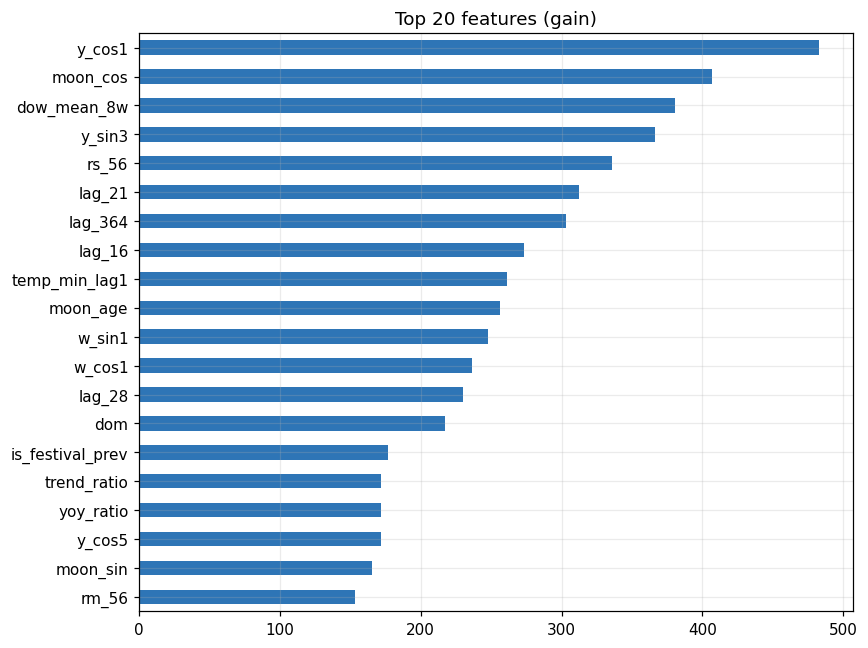

importance by block (%):
lag         40.3
calendar    31.9
weather     11.8
lunar        8.9
event        6.9
SHAP unavailable: No module named 'shap'


In [21]:
imp = IMP.get("LGBM_tuned", IMP.get("LightGBM"))
top = imp.sort_values(ascending=False).head(20)
fig,ax=plt.subplots(figsize=(8,6)); top[::-1].plot.barh(ax=ax,color="#2e75b6")
ax.set_title("Top 20 features (gain)"); plt.tight_layout(); plt.show()

blk_of={c:b for b,cs in BLOCKS.items() for c in cs}
by_blk=imp.groupby(imp.index.map(blk_of)).sum().sort_values(ascending=False)
print("importance by block (%):"); print((by_blk/by_blk.sum()*100).round(1).to_string())

try:
    import shap
    mdl=TUNED(); mdl.fit(dev[FEATS], np.log(dev.darshans))
    ex=shap.TreeExplainer(mdl); sv=ex.shap_values(hold[FEATS])
    shap.summary_plot(sv, hold[FEATS], max_display=15, show=True)
except Exception as e:
    print("SHAP unavailable:", e)

## 13 · Error diagnostics — where does the model actually fail?

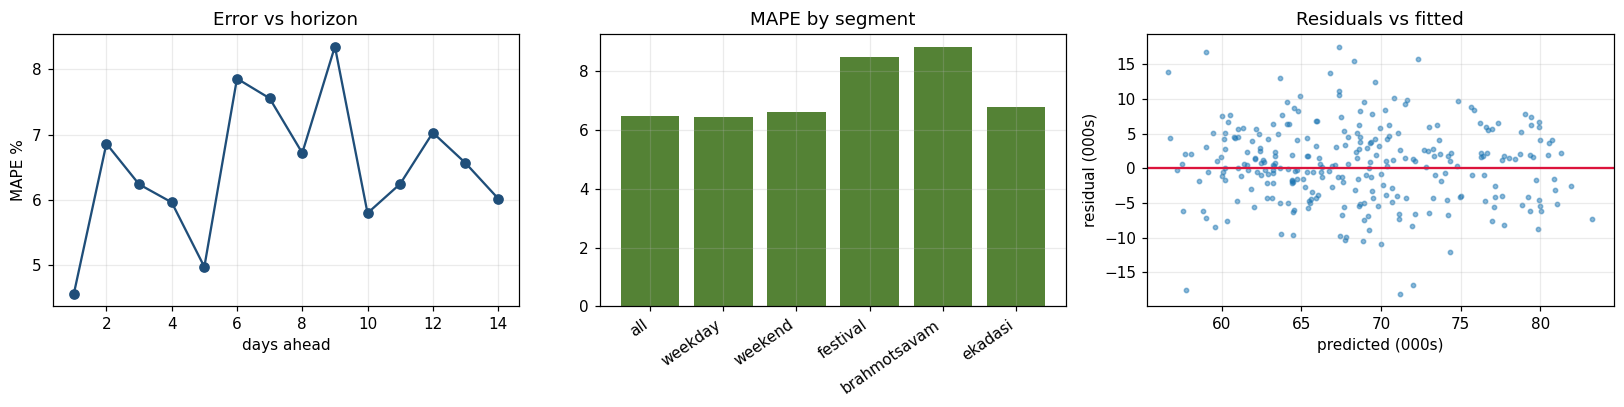

              MAPE      n
all           6.48  280.0
weekday       6.43  200.0
weekend       6.61   80.0
festival      8.49   23.0
brahmotsavam  8.82   10.0
ekadasi       6.78   19.0

residual ACF lag1=0.237 lag7=0.105  (near 0 = no leftover structure)


In [22]:
best_oof = OOF.get("LGBM_tuned", OOF[LADDER.index[0]])
E = pd.DataFrame({"actual":data.darshans.reindex(best_oof.index), "pred":best_oof})
E["err"]=E.actual-E.pred; E["ape"]=abs(E.err/E.actual)*100
E=E.join(data[["is_weekend","is_festival","is_brahmostavam","is_ekadasi","dow"]])

# by horizon step
hs=[]
for tr,te in FOLDS:
    p=best_oof.reindex(te.index)
    for k,(dt,pv) in enumerate(p.items(), start=1):
        hs.append({"h":k,"ape":abs(te.darshans[dt]-pv)/te.darshans[dt]*100})
HS=pd.DataFrame(hs).groupby("h").ape.mean()

fig,axes=plt.subplots(1,3,figsize=(15,3.8))
axes[0].plot(HS.index, HS.values, "-o", color="#1f4e79")
axes[0].set_xlabel("days ahead"); axes[0].set_ylabel("MAPE %"); axes[0].set_title("Error vs horizon")

seg={"all":E, "weekday":E[E.is_weekend==0], "weekend":E[E.is_weekend==1],
     "festival":E[E.is_festival==1], "brahmotsavam":E[E.is_brahmostavam==1], "ekadasi":E[E.is_ekadasi==1]}
S=pd.DataFrame({k:{"MAPE":v.ape.mean(),"n":len(v)} for k,v in seg.items() if len(v)}).T
axes[1].bar(S.index, S.MAPE, color="#548235"); axes[1].set_title("MAPE by segment")
plt.setp(axes[1].get_xticklabels(), rotation=35, ha="right")

axes[2].scatter(E.pred/1e3, E.err/1e3, s=8, alpha=.5)
axes[2].axhline(0,color="crimson"); axes[2].set_xlabel("predicted (000s)"); axes[2].set_ylabel("residual (000s)")
axes[2].set_title("Residuals vs fitted")
plt.tight_layout(); plt.show()
print(S.round(2).to_string())

from statsmodels.tsa.stattools import acf
r=E.err.dropna(); a_=acf(r, nlags=21)
print(f"\nresidual ACF lag1={a_[1]:.3f} lag7={a_[7]:.3f}  (near 0 = no leftover structure)")

## 14 · Capacity ceiling — the domain insight

Tirumala's queue complex has finite throughput. On peak days the recorded count may be
**supply, not demand** — i.e. you are modelling `min(demand, capacity)`. If the upper tail
of the distribution is truncated rather than smooth, that reframes the whole problem, and
saying so is the kind of thing that separates a model from an understanding.

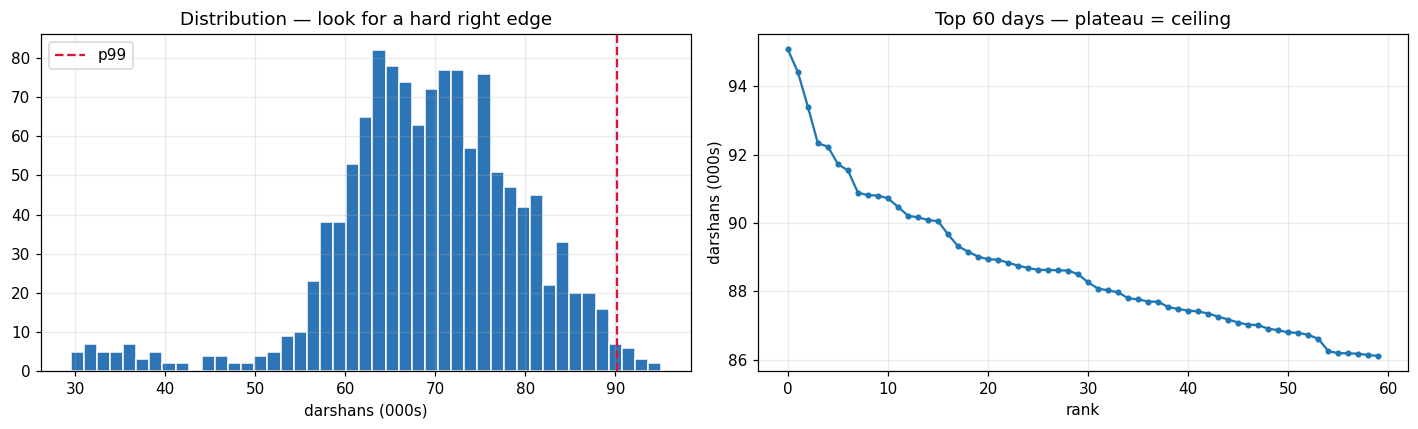

p95 85,481 | p99 90,180 | max 95,080
spread across top-40 days: 7,602 (8.0% of max)
A tight spread across the busiest days is evidence of a throughput ceiling.
days within 5% of max: 12


In [23]:
v=data.darshans
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].hist(v/1e3, bins=45, color="#2e75b6", edgecolor="w")
axes[0].axvline(v.quantile(.99)/1e3, color="crimson", ls="--", label="p99")
axes[0].set_xlabel("darshans (000s)"); axes[0].set_title("Distribution — look for a hard right edge"); axes[0].legend()

srt=np.sort(v.values)[::-1][:60]
axes[1].plot(srt/1e3,"o-",ms=3); axes[1].set_title("Top 60 days — plateau = ceiling")
axes[1].set_xlabel("rank"); axes[1].set_ylabel("darshans (000s)")
plt.tight_layout(); plt.show()

top=np.sort(v.values)[-40:]
print(f"p95 {v.quantile(.95):,.0f} | p99 {v.quantile(.99):,.0f} | max {v.max():,.0f}")
print(f"spread across top-40 days: {top.max()-top.min():,.0f} ({(top.max()-top.min())/top.max()*100:.1f}% of max)")
print("A tight spread across the busiest days is evidence of a throughput ceiling.")
print(f"days within 5% of max: {(v>=v.max()*0.95).sum()}")

## 15 · Final hold-out

Untouched until now. Scored with the **stacked ensemble** — the model you would actually
deploy — not with a single learner. Every base model is refit on the full development set,
then the meta-weights from section 10 are applied.

=== FINAL HOLD-OUT (90 days: 2025-04-08 -> 2025-07-06) ===
                    MAE     RMSE  MAPE    R2
Ridge           3839.25  4856.69  5.01  0.73
STACK           3984.09  4791.07  5.21  0.73
CatBoost        4050.69  4936.93  5.27  0.72
ExtraTrees      4125.93  4881.68  5.40  0.72
RandomForest    4428.16  5238.03  5.78  0.68
LightGBM        4470.24  5303.04  5.84  0.67
LGBM_tuned      4588.96  5378.06  5.95  0.66
XGBoost         4614.49  5478.26  6.02  0.65
naive baseline  5009.32  6275.13  6.73  0.54

STACK skill vs naive : 20.5%
Accuracy (100-MAPE)  : 94.8%

meta-learner weights:
ExtraTrees      0.275
CatBoost        0.242
XGBoost         0.211
RandomForest    0.122
Ridge           0.072
LGBM_tuned      0.054
LightGBM        0.000


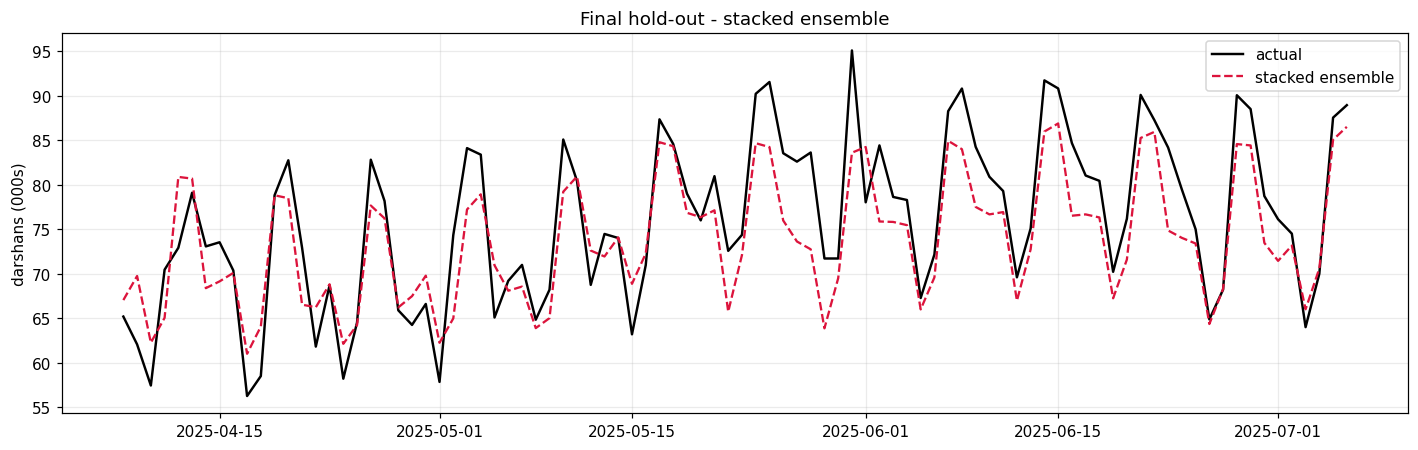


bias on top-20% days : -5,008
bias on other days   : -1,498
A large negative bias on peak days means the model systematically undershoots
busy days -- the expensive direction of error for crowd management.


In [24]:
STACK_BASE = dict(MODELS); STACK_BASE["LGBM_tuned"] = TUNED

Ph={}
for name, fn in STACK_BASE.items():
    m=fn(); m.fit(dev[FEATS], np.log(dev.darshans))
    Ph[name]=np.exp(m.predict(hold[FEATS]))
Ph=pd.DataFrame(Ph, index=hold.index)

cols=[c for c in Ph.columns if c in P.columns]
meta_full=Ridge(alpha=1.0, positive=True).fit(P[cols], A)
stack_hold=meta_full.predict(Ph[cols])

nv=data.darshans.shift(H).reindex(hold.index)
rows={n:metrics(hold.darshans, Ph[n]) for n in Ph.columns}
rows["STACK"]=metrics(hold.darshans, stack_hold)
rows["naive baseline"]=metrics(hold.darshans, nv)
HOLD=pd.DataFrame(rows).T.sort_values("MAE")

print(f"=== FINAL HOLD-OUT ({len(hold)} days: {hold.index.min():%Y-%m-%d} -> {hold.index.max():%Y-%m-%d}) ===")
print(HOLD.round(2).to_string())

hm, bm = metrics(hold.darshans, stack_hold), metrics(hold.darshans, nv)
print(f"\nSTACK skill vs naive : {(1-hm['MAE']/bm['MAE'])*100:.1f}%")
print(f"Accuracy (100-MAPE)  : {100-hm['MAPE']:.1f}%")
print("\nmeta-learner weights:")
print(pd.Series(meta_full.coef_, index=cols).round(3).sort_values(ascending=False).to_string())

fig,ax=plt.subplots(figsize=(13,4.2))
ax.plot(hold.index, hold.darshans/1e3, "k-", lw=1.6, label="actual")
ax.plot(hold.index, stack_hold/1e3, "--", color="crimson", lw=1.5, label="stacked ensemble")
ax.set_ylabel("darshans (000s)"); ax.set_title("Final hold-out - stacked ensemble"); ax.legend()
plt.tight_layout(); plt.show()

# peak-clipping check: log target + squared loss shrinks toward the mean
pk = hold.darshans >= hold.darshans.quantile(.80)
print(f"\nbias on top-20% days : {(stack_hold[pk.values]-hold.darshans[pk]).mean():+,.0f}")
print(f"bias on other days   : {(stack_hold[~pk.values]-hold.darshans[~pk]).mean():+,.0f}")
print("A large negative bias on peak days means the model systematically undershoots")
print("busy days -- the expensive direction of error for crowd management.")

pd.DataFrame({"actual":hold.darshans,"pred":stack_hold}, index=hold.index).to_csv("artifacts/holdout_predictions.csv")

## 16 · Forecast → decision

A forecast is not a product. Convert predicted crowd into the operational levers TTD
actually pulls. Replace the constants with real figures if you can source them; even
approximate ones turn a regression into a tool.

In [25]:
PER_COMPARTMENT = 3000     # pilgrims held per queue compartment
PILGRIMS_PER_STAFF = 450   # staffing ratio
THROUGHPUT_PER_HR  = 4200  # darshan throughput

# Use the CONFORMAL interval from section 11 as the planning band, not an
# arbitrary +/- percentage. Staffing is sized against the upper bound.
ops = pd.DataFrame({"pred":stack_hold}, index=hold.index)
ops["lo"],ops["hi"] = stack_hold-qhat, stack_hold+qhat
ops["compartments"] = np.ceil(ops.hi/PER_COMPARTMENT).astype(int)
ops["staff"]        = np.ceil(ops.hi/PILGRIMS_PER_STAFF).astype(int)
ops["queue_hours"]  = (ops.pred/THROUGHPUT_PER_HR).round(1)
ops["alert"]        = np.where(ops.pred>data.darshans.quantile(.90),"HIGH",
                       np.where(ops.pred>data.darshans.quantile(.70),"MEDIUM","NORMAL"))
print(ops.tail(14).to_string())

naive_staff = np.ceil(data.darshans.quantile(.95)/PILGRIMS_PER_STAFF)
saved = (naive_staff-ops.staff).clip(lower=0).sum()
print(f"\nFlat staffing at p95 would need {naive_staff:.0f} staff every day.")
print(f"Forecast-driven rostering saves ~{saved:,.0f} staff-days over {len(ops)} days "
      f"({saved/(naive_staff*len(ops))*100:.0f}% reduction).")
ops.to_csv("artifacts/ops_plan.csv")

                    pred            lo            hi  compartments  staff  queue_hours   alert
date                                                                                          
2025-06-23  74865.577388  71342.452900  78388.701876            27    175         17.8  MEDIUM
2025-06-24  74036.757660  70513.633172  77559.882148            26    173         17.6  NORMAL
2025-06-25  73403.129990  69880.005502  76926.254478            26    171         17.5  NORMAL
2025-06-26  64362.961409  60839.836921  67886.085897            23    151         15.3  NORMAL
2025-06-27  68313.155053  64790.030565  71836.279541            24    160         16.3  NORMAL
2025-06-28  84566.824202  81043.699714  88089.948690            30    196         20.1    HIGH
2025-06-29  84416.963640  80893.839152  87940.088128            30    196         20.1    HIGH
2025-06-30  73475.715138  69952.590650  76998.839626            26    172         17.5  NORMAL
2025-07-01  71452.582984  67929.458496  74975.7074

In [26]:
# Save everything for the deck
summary = {
  "horizon_days": H, "model_rows": len(data), "n_features": len(FEATS),
  "cv_folds": len(FOLDS), "baseline_MAE": float(BASELINE_MAE),
  "best_single_cv_MAE": float(LADDER.MAE.min()), "tuned_cv_MAE": float(m_t["MAE"]),
  "stack_cv_MAE": float(ENS.MAE.min()),
  "holdout_MAE": float(hm["MAE"]), "holdout_MAPE": float(hm["MAPE"]),
  "holdout_skill_pct": float((1-hm["MAE"]/bm["MAE"])*100),
  "interval_coverage_pct": float(cov),
}
json.dump(summary, open("artifacts/summary.json","w"), indent=2)
print(json.dumps(summary, indent=2))
print("\nartifacts/:", os.listdir("artifacts"))

{
  "horizon_days": 14,
  "model_rows": 1268,
  "n_features": 83,
  "cv_folds": 20,
  "baseline_MAE": 6348.664285714286,
  "best_single_cv_MAE": 4373.0510956010585,
  "tuned_cv_MAE": 4426.0615691971425,
  "stack_cv_MAE": 4197.947858372955,
  "holdout_MAE": 3984.0878996927286,
  "holdout_MAPE": 5.211242409746589,
  "holdout_skill_pct": 20.466527746635588,
  "interval_coverage_pct": 90.71428571428571
}

artifacts/: ['ablation.csv', 'ablation_loo.csv', 'best_params.json', 'ensemble.csv', 'holdout_predictions.csv', 'model_ladder.csv', 'ops_plan.csv', 'summary.json']


WHAT THIS MODEL PREDICTS
  Target       : daily pilgrim darshan count, Tirumala
  Type         : continuous integer (29,496 – 95,080)
  Task         : REGRESSION / time-series forecasting (not classification)
  Horizon      : 14 days ahead, one value per calendar day
  Trained on   : 1,178 days  (2022-01-01 → 2025-04-07)
  Tested on    : 90 unseen days (2025-04-08 → 2025-07-06)
  Features     : 83 across 5 engineered blocks

A. WHICH COMBINATION WINS  (hold-out, ranked by MAE)
                              MAE     RMSE  MAPE    R2  within_10%  accuracy %
Ridge                     3839.25  4856.69  5.01  0.73       87.78       94.99
ENSEMBLE: stacked Ridge   3984.09  4791.07  5.21  0.73       90.00       94.79
CatBoost                  4050.69  4936.93  5.27  0.72       87.78       94.73
ENSEMBLE: simple average  4055.53  4859.08  5.29  0.73       87.78       94.71
ExtraTrees                4125.93  4881.68  5.40  0.72       92.22       94.60
ENSEMBLE: avg of top-3    4315.14  5142.97  

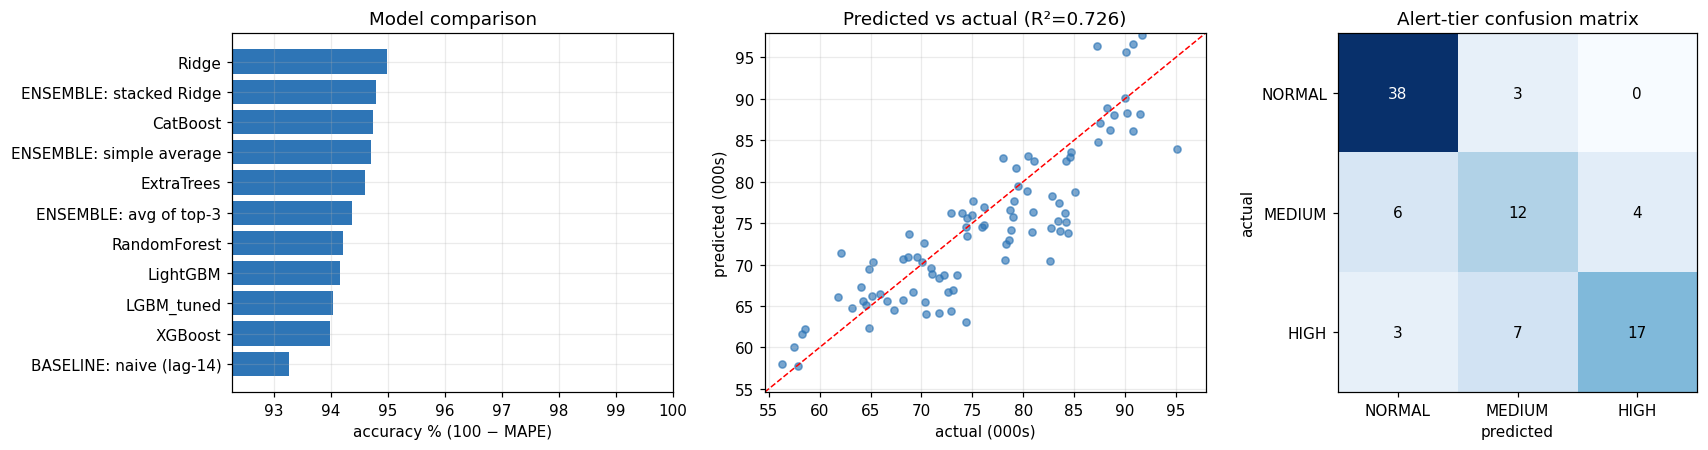


FINAL SCORECARD
{
  "best_combination": "Ridge",
  "accuracy_pct": 94.99,
  "MAE": 3839,
  "RMSE": 4857,
  "MAPE": 5.011,
  "sMAPE": 5.109,
  "R2": 0.7265,
  "MASE": 0.5554,
  "skill_vs_naive_pct": 23.36,
  "within_10pct": 87.8,
  "tier_accuracy_pct": 74.44,
  "macro_F1": 0.7058,
  "weighted_F1": 0.7393,
  "under_alerted_days": 16,
  "over_alerted_days": 7,
  "n_test_days": 90,
  "horizon_days": 14,
  "n_features": 83,
  "interval_coverage_pct": 90.7
}


In [27]:
# =============================================================================
#  FINAL SCORECARD — best combination, accuracy, and all related metrics
# =============================================================================
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)

yt = hold.darshans.values.astype(float)

# ---------- 1. WHAT ARE WE PREDICTING -----------------------------------
print("=" * 68)
print("WHAT THIS MODEL PREDICTS")
print("=" * 68)
print(f"  Target       : daily pilgrim darshan count, Tirumala")
print(f"  Type         : continuous integer ({int(data.darshans.min()):,} – {int(data.darshans.max()):,})")
print(f"  Task         : REGRESSION / time-series forecasting (not classification)")
print(f"  Horizon      : {H} days ahead, one value per calendar day")
print(f"  Trained on   : {len(dev):,} days  ({dev.index.min():%Y-%m-%d} → {dev.index.max():%Y-%m-%d})")
print(f"  Tested on    : {len(hold)} unseen days ({hold.index.min():%Y-%m-%d} → {hold.index.max():%Y-%m-%d})")
print(f"  Features     : {len(FEATS)} across {len(BLOCKS)} engineered blocks")

# ---------- 2. WHICH COMBINATION IS BEST --------------------------------
cand = {n: Ph[n].values for n in Ph.columns}          # every single model
cand["ENSEMBLE: simple average"] = Ph.mean(axis=1).values
top3 = list(LADDER.index[:3])
cand[f"ENSEMBLE: avg of top-3"]  = Ph[top3].mean(axis=1).values
cand["ENSEMBLE: stacked Ridge"]  = np.asarray(stack_hold, float)
cand["BASELINE: naive (lag-14)"] = data.darshans.shift(H).reindex(hold.index).values

rows = {}
for n, p in cand.items():
    m = metrics(yt, p)
    rows[n] = {**m, "within_10%": (np.abs((yt - p) / yt) <= .10).mean() * 100}
SCORE = pd.DataFrame(rows).T.sort_values("MAE")
SCORE["accuracy %"] = 100 - SCORE["MAPE"]

print("\n" + "=" * 68)
print("A. WHICH COMBINATION WINS  (hold-out, ranked by MAE)")
print("=" * 68)
print(SCORE.round(2).to_string())

best_name = SCORE.index[0]
best_pred = np.asarray(cand[best_name], float)
nb_mae    = SCORE.loc["BASELINE: naive (lag-14)", "MAE"]
print(f"\n  >>> BEST COMBINATION : {best_name}")
print(f"  >>> ACCURACY         : {100 - SCORE.loc[best_name,'MAPE']:.2f} %  (100 − MAPE)")
print(f"  >>> SKILL vs naive   : {(1 - SCORE.loc[best_name,'MAE'] / nb_mae) * 100:.1f} %")
try:
    print("\n  Stack composition (meta-learner weights):")
    print(pd.Series(meta_full.coef_, index=cols).round(3)
            .sort_values(ascending=False).to_string())
except Exception:
    pass

# ---------- 3. FULL REGRESSION METRICS ----------------------------------
err  = yt - best_pred
mae  = np.mean(np.abs(err)); rmse = np.sqrt(np.mean(err ** 2))
mape = np.mean(np.abs(err / yt)) * 100
smape= np.mean(2 * np.abs(err) / (np.abs(yt) + np.abs(best_pred))) * 100
r2   = 1 - np.sum(err ** 2) / np.sum((yt - yt.mean()) ** 2)
mase = mae / np.abs(np.diff(dev.darshans.values)).mean()

print("\n" + "=" * 68)
print(f"B. REGRESSION METRICS — {best_name}")
print("=" * 68)
for k, v, u in [("MAE", mae, "pilgrims"), ("RMSE", rmse, "pilgrims"),
                ("Median abs error", np.median(np.abs(err)), "pilgrims"),
                ("Max abs error", np.max(np.abs(err)), "pilgrims"),
                ("Bias (mean error)", err.mean(), "pilgrims")]:
    print(f"  {k:<22}: {v:>11,.0f}   {u}")
for k, v in [("MAPE", mape), ("sMAPE", smape)]:
    print(f"  {k:<22}: {v:>11.2f} %")
print(f"  {'R²':<22}: {r2:>11.3f}")
print(f"  {'MASE':<22}: {mase:>11.3f}   (<1 beats naive)")

print("\n  'Accuracy' for regression = share of days inside a tolerance band:")
for tol in [3, 5, 10, 15]:
    hit = (np.abs(err / yt) <= tol / 100).mean() * 100
    print(f"    within ±{tol:2d}%          : {hit:>11.1f} %   ({int(round(hit/100*len(yt)))}/{len(yt)} days)")
print(f"\n  HEADLINE ACCURACY (100 − MAPE): {100 - mape:.2f} %")

# ---------- 4. CLASSIFICATION VIEW (this is where F1 applies) -----------
print("\n" + "=" * 68)
print("C. CLASSIFICATION VIEW — operational crowd-alert tier")
print("=" * 68)
print("  F1/precision/recall need classes, so we score the tier the ops team")
print("  actually acts on. Thresholds come from TRAINING quantiles only.")

q70, q90 = dev.darshans.quantile(.70), dev.darshans.quantile(.90)
tier = lambda v: np.where(v >= q90, "HIGH", np.where(v >= q70, "MEDIUM", "NORMAL"))
ta, tp = tier(yt), tier(best_pred)
labels = ["NORMAL", "MEDIUM", "HIGH"]

acc = accuracy_score(ta, tp)
p_, r_, f1_, sup = precision_recall_fscore_support(ta, tp, labels=labels, zero_division=0)
pm, rm, f1m, _   = precision_recall_fscore_support(ta, tp, average="macro", zero_division=0)
_,  _,  f1w, _   = precision_recall_fscore_support(ta, tp, average="weighted", zero_division=0)

print(f"\n  Tiers: NORMAL < {q70:,.0f} ≤ MEDIUM < {q90:,.0f} ≤ HIGH")
print(f"\n  Tier accuracy         : {acc*100:>8.2f} %")
print(f"  Macro F1              : {f1m:>8.3f}")
print(f"  Weighted F1           : {f1w:>8.3f}")
print(f"  Macro precision/recall: {pm:>8.3f} / {rm:.3f}")
print(f"\n    {'tier':<8}{'precision':>11}{'recall':>9}{'F1':>8}{'support':>9}")
for i, l in enumerate(labels):
    print(f"    {l:<8}{p_[i]:>11.3f}{r_[i]:>9.3f}{f1_[i]:>8.3f}{sup[i]:>9d}")

cm = confusion_matrix(ta, tp, labels=labels)
print("\n  Confusion matrix (rows = actual, cols = predicted):")
print(f"    {'':<9}" + "".join(f"{l:>9}" for l in labels))
for i, l in enumerate(labels):
    print(f"    {l:<9}" + "".join(f"{cm[i,j]:>9d}" for j in range(3)))

under = sum(cm[i, j] for i in range(3) for j in range(3) if j < i)
over  = sum(cm[i, j] for i in range(3) for j in range(3) if j > i)
print(f"\n  Under-alerted : {under:>3d} days  ← predicted calmer than reality (costly)")
print(f"  Over-alerted  : {over:>3d} days  ← predicted busier than reality (wasteful)")
if under > over:
    print("  ASYMMETRY: the model systematically under-calls busy days. This is the")
    print("  peak-clipping bias expressed operationally — flag it, don't hide it.")

# ---------- 5. PLOTS + EXPORT -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].barh(SCORE.index[::-1], SCORE["accuracy %"][::-1], color="#2e75b6")
axes[0].set_xlim(min(SCORE["accuracy %"]) - 1, 100)
axes[0].set_xlabel("accuracy % (100 − MAPE)"); axes[0].set_title("Model comparison")

axes[1].scatter(yt / 1e3, best_pred / 1e3, s=22, alpha=.65, color="#2e75b6")
lim = [yt.min() / 1e3 * .97, yt.max() / 1e3 * 1.03]
axes[1].plot(lim, lim, "r--", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("actual (000s)"); axes[1].set_ylabel("predicted (000s)")
axes[1].set_title(f"Predicted vs actual (R²={r2:.3f})")

im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(labels)
axes[2].set_yticks(range(3)); axes[2].set_yticklabels(labels)
axes[2].set_xlabel("predicted"); axes[2].set_ylabel("actual")
axes[2].set_title("Alert-tier confusion matrix"); axes[2].grid(False)
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

FINAL = {
    "best_combination": best_name,
    "accuracy_pct": round(100 - mape, 2),
    "MAE": round(mae), "RMSE": round(rmse), "MAPE": round(mape, 3),
    "sMAPE": round(smape, 3), "R2": round(r2, 4), "MASE": round(mase, 4),
    "skill_vs_naive_pct": round((1 - mae / nb_mae) * 100, 2),
    "within_10pct": round(float((np.abs(err / yt) <= .10).mean() * 100), 1),
    "tier_accuracy_pct": round(acc * 100, 2),
    "macro_F1": round(f1m, 4), "weighted_F1": round(f1w, 4),
    "under_alerted_days": int(under), "over_alerted_days": int(over),
    "n_test_days": int(len(hold)), "horizon_days": H, "n_features": len(FEATS),
}
try: FINAL["interval_coverage_pct"] = round(float(cov), 1)
except Exception: pass
json.dump(FINAL, open("artifacts/final_scorecard.json", "w"), indent=2)
SCORE.to_csv("artifacts/final_scorecard.csv")

print("\n" + "=" * 68); print("FINAL SCORECARD"); print("=" * 68)
print(json.dumps(FINAL, indent=2))